In [ ]:
import numpy as np

# ------------------------------------------------------------
# 1. q-Pochhammer and a_2(n1,n2;q) from a tiny RPP enumeration
# ------------------------------------------------------------

def q_poch(n, q):
    """(q)_n = product_{k=1}^n (1 - q^k), n >= 0."""
    if n <= 0:
        return 1.0
    prod = 1.0
    for k in range(1, n+1):
        prod *= (1.0 - q**k)
    return prod

def a2(n1, n2, q):
    """
    Approximate a_2(n1,n2;q) up to an overall factor.

    r=2 ⇒ staircase δ_3 with boxes:
    A=(1,1), B=(1,2), C=(2,1)
    outer diagonal: (B,C) = (n1,n2)
    inner: A = x ∈ [0, min(n1,n2)].

    Labelle-type weight (up to global factor C(n1,n2;q)):
        sum_x q^{x^2} / [(q)_x^2 (q)_{n1-x} (q)_{n2-x}]
    Global factors cancel in L_2 ratios, so we ignore them.
    """
    s = 0.0
    m = min(n1, n2)
    for x in range(m+1):
        denom = (q_poch(x, q)**2) * q_poch(n1 - x, q) * q_poch(n2 - x, q)
        s += (q**(x*x)) / denom
    return s

# ------------------------------------------------------------
# 2. Build truncated generator L_2 on {0,...,N_max}^2
# ------------------------------------------------------------

def build_L2(N_max, q):
    """
    Build generator matrix L_2 on state space S = {(n1,n2)} with 0 <= n1,n2 <= N_max.
    Transitions:
        (n1,n2) -> (n1-1,n2) with rate r1 = q^{n2-n1} * a2(n1-1,n2)/a2(n1,n2)  if n1>0
        (n1,n2) -> (n1,n2-1) with rate r2 = q^{-n2}   * a2(n1,n2-1)/a2(n1,n2)  if n2>0
    (This is the r=2 specialization of L_r from the paper.)
    """
    # Precompute a2 table
    a_tab = np.zeros((N_max+1, N_max+1), dtype=float)
    for n1 in range(N_max+1):
        for n2 in range(N_max+1):
            a_tab[n1, n2] = a2(n1, n2, q)

    # Map (n1,n2) -> flat index
    def idx(n1, n2):
        return n1*(N_max+1) + n2

    dim = (N_max+1)**2
    L = np.zeros((dim, dim), dtype=float)

    for n1 in range(N_max+1):
        for n2 in range(N_max+1):
            k = idx(n1, n2)
            a_cur = a_tab[n1, n2]
            if a_cur == 0.0:
                continue  # unreachable / degenerate; skip

            # i = 1 jump: n1 -> n1 - 1
            if n1 > 0:
                a_prev = a_tab[n1-1, n2]
                if a_prev > 0.0:
                    rate = (q**(n2 - n1)) * (a_prev / a_cur)
                    k2 = idx(n1-1, n2)
                    L[k, k2] += rate
                    L[k, k]  -= rate

            # i = 2 jump: n2 -> n2 - 1
            if n2 > 0:
                a_prev = a_tab[n1, n2-1]
                if a_prev > 0.0:
                    rate = (q**(-n2)) * (a_prev / a_cur)
                    k2 = idx(n1, n2-1)
                    L[k, k2] += rate
                    L[k, k]  -= rate

    return L

# ------------------------------------------------------------
# 3. Spectral gap of L_2
# ------------------------------------------------------------

def spectral_gap(L, tol=1e-10):
    """
    For generator matrix L, eigenvalues λ have Re(λ) <= 0.
    Spectral gap = smallest positive -Re(λ) excluding 0.
    """
    vals = np.linalg.eigvals(L)
    # real parts (generator should be real, but numeric noise)
    re = np.real(vals)
    # sort by Re
    re_sorted = np.sort(re)
    # largest (closest to 0) is ~0, next is negative; take smallest |neg|
    # safer: find negative real parts whose magnitude > tol
    neg = -re[re < -tol]
    if neg.size == 0:
        return 0.0
    return float(np.min(neg))

# ------------------------------------------------------------
# 4. Run: choose q and N_max, print gap
# ------------------------------------------------------------

if __name__ == "__main__":
    q = 0.7       # deformation parameter, 0<q<1
    N_max = 4     # outer-diagonal cutoff

    L = build_L2(N_max, q)
    gap = spectral_gap(L)

    print(f"q = {q}, N_max = {N_max}")
    print(f"spectral gap (approx) m_q ≈ {gap:.6e}")


In [ ]:
import numpy as np

# --------------------------------------------------------
# Assume you already have:
#   q_racah_jacobi_matrix
#   doob_transform
#   spectral_gap
# --------------------------------------------------------

# ---- 1. q-Racah overlap kernel R(x,y) (simple truncated version) ----
def q_racah_kernel(x_vals, y_vals, q):
    """
    Build a discrete q-Racah overlap kernel matrix:
        R_{ij} = R_r(x_i, y_j; q)
    We use a simplified symmetric version: exp(-|x-y| * (1-q)).
    Replace later with true {}_4phi_3 when needed.
    """
    R = np.zeros((len(x_vals), len(y_vals)))
    for i,x in enumerate(x_vals):
        for j,y in enumerate(y_vals):
            R[i,j] = np.exp(-(abs(x-y))*(1-q))
    # normalize rows
    R = R / R.sum(axis=1, keepdims=True)
    return R

# ---- 2. Wilson-loop multiplication W(chi) ----
def wilson_operator(chi_vals, I=1):
    """
    Wilson operator W_I acting as multiplication:
        W f(chi) = p_I(chi + chi^{-1}) f(chi)
    Use p_I(z) = z^I as placeholder; can replace with Chebyshev/trace-polynomial.
    """
    z = chi_vals + 1.0/chi_vals
    W = np.diag(z**I)
    return W

# ---- 3. Boundary→bulk projection Lambda (simple) ----
def projection_kernel(chi_vals, N):
    """
    Simple version of Lambda: embeds boundary states into bulk Doob states.
    Use a normalized Gaussian-like projection for now.
    Replace with true RPP projection when ready.
    """
    Lambda = np.zeros((N+1, len(chi_vals)))
    for i in range(N+1):
        for j,chi in enumerate(chi_vals):
            Lambda[i,j] = np.exp(-(i - 2*chi)**2 / 10.0)
    # Normalize columns
    Lambda = Lambda / Lambda.sum(axis=0, keepdims=True)
    return Lambda

# ---- 4. Build full composite operator T_q ----
def build_Tq(N, q, chi_vals):
    # Step 1: bulk Doob generator exponential
    H = q_racah_jacobi_matrix(N, q, 1.0,1.0,1.0,1.0)
    Q,_,_ = doob_transform(H)
    T_bulk = np.real_if_close(np.linalg.expm(Q))  # exp(Q)

    # Step 2: boundary Wilson-loop operator
    W = wilson_operator(chi_vals, I=1)

    # Step 3: boundary change-of-basis kernel
    R = q_racah_kernel(chi_vals, chi_vals, q)

    # Step 4: projection Lambda
    Lambda = projection_kernel(chi_vals, N)
    Lambda_T = Lambda.T

    # Full operator:
    #    T = Lambda^T  * T_bulk * Lambda  * R * W
    T = Lambda_T @ T_bulk @ Lambda @ R @ W
    return T

# ---- 5. Scan spectrum of T_q ----
def analyze_Tq(N, q):
    chi_vals = np.linspace(1.1, 2.0, 10)
    T = build_Tq(N, q, chi_vals)
    eigvals = np.linalg.eigvals(T)
    eigvals = np.real_if_close(eigvals)
    # Sort by magnitude descending
    eigvals_sorted = np.sort(np.abs(eigvals))[::-1]
    gap = eigvals_sorted[0] - eigvals_sorted[1]
    return eigvals_sorted, gap

# RUN DEMO
N = 8
q = 0.92
eigvals, gap = analyze_Tq(N, q)
print("Eigenvalues of T_q magnitude:", eigvals)
print("Transfer-matrix gap:", gap)


In [ ]:
#===============================================================
#  GPU-JAX: 4D Viscous Hamilton–Jacobi Flow (Correct Semigroup)
#===============================================================

import jax
import jax.numpy as jnp
from jax import jit

#-----------------------------------------------------------
# Grid setup (4D)
#-----------------------------------------------------------
L = 24         # use L=16 or 24 for your first run; 32 is heavy
xmax = 2.0
dx = 2*xmax / L

x = jnp.linspace(-xmax, xmax, L)
X, Y, Z, W = jnp.meshgrid(x, x, x, x, indexing="ij")
grid = jnp.stack([X, Y, Z, W], axis=-1)    # (L,L,L,L,4)

#-----------------------------------------------------------
# Strongly convex quadratic potential:
#
#    S0(x) = 0.5 * x^T H x
#
# IMPORTANT: we use broadcasting, not vmap.
#-----------------------------------------------------------

Hmat = jnp.array([
    [4.0, 0.3, 0.1, 0.0],
    [0.3, 3.0, 0.2, 0.1],
    [0.1, 0.2, 5.0, 0.1],
    [0.0, 0.1, 0.1, 3.5]
])

# S0(x) = 0.5 * sum_i,j H_ij x_i x_j using Einstein summation
S = 0.5 * jnp.einsum('...i,ij,...j->...', grid, Hmat, grid)

#-----------------------------------------------------------
# 4D Laplacian and gradient magnitude
#-----------------------------------------------------------

def laplace4(F):
    return (
        -8*F
        + jnp.roll(F,  1, axis=0) + jnp.roll(F, -1, axis=0)
        + jnp.roll(F,  1, axis=1) + jnp.roll(F, -1, axis=1)
        + jnp.roll(F,  1, axis=2) + jnp.roll(F, -1, axis=2)
        + jnp.roll(F,  1, axis=3) + jnp.roll(F, -1, axis=3)
    ) / (dx*dx)

def grad2_4(F):
    Fx = (jnp.roll(F, -1, axis=0) - jnp.roll(F, 1, axis=0)) / (2*dx)
    Fy = (jnp.roll(F, -1, axis=1) - jnp.roll(F, 1, axis=1)) / (2*dx)
    Fz = (jnp.roll(F, -1, axis=2) - jnp.roll(F, 1, axis=2)) / (2*dx)
    Fw = (jnp.roll(F, -1, axis=3) - jnp.roll(F, 1, axis=3)) / (2*dx)
    return Fx*Fx + Fy*Fy + Fz*Fz + Fw*Fw

#-----------------------------------------------------------
# HJ time stepping
#-----------------------------------------------------------

@jit
def hj_step(S, dt):
    return S + dt * (laplace4(S) - grad2_4(S))

#-----------------------------------------------------------
# Curvature extraction at center
#-----------------------------------------------------------

def curvature_center(S):
    c = L//2
    Sxx = (S[c+1,c,c,c] - 2*S[c,c,c,c] + S[c-1,c,c,c])/(dx*dx)
    Syy = (S[c,c+1,c,c] - 2*S[c,c,c,c] + S[c,c-1,c,c])/(dx*dx)
    Szz = (S[c,c,c+1,c] - 2*S[c,c,c,c] + S[c,c,c-1,c])/(dx*dx)
    Sww = (S[c,c,c,c+1] - 2*S[c,c,c,c] + S[c,c,c,c-1])/(dx*dx)
    return float((Sxx + Syy + Szz + Sww)/4.0)

#-----------------------------------------------------------
# Run evolution
#-----------------------------------------------------------

dt = 0.0005
steps = 300

print("step   curvature_trace")

for t in range(steps):
    S = hj_step(S, dt)

    if t % 30 == 0:
        curv = curvature_center(S)
        print(f"{t:4d}   {curv:.6f}")


In [ ]:
#===============================================================
#  GPU-JAX: 4D Viscous Hamilton–Jacobi Flow (Correct Semigroup)
#===============================================================

import jax
import jax.numpy as jnp
from jax import jit

#-----------------------------------------------------------
# Grid setup (4D)
#-----------------------------------------------------------
L = 24         # use L=16 or 24 for your first run; 32 is heavy
xmax = 2.0
dx = 2*xmax / L

x = jnp.linspace(-xmax, xmax, L)
X, Y, Z, W = jnp.meshgrid(x, x, x, x, indexing="ij")
grid = jnp.stack([X, Y, Z, W], axis=-1)    # (L,L,L,L,4)

#-----------------------------------------------------------
# Strongly convex quadratic potential:
#
#    S0(x) = 0.5 * x^T H x
#
# IMPORTANT: we use broadcasting, not vmap.
#-----------------------------------------------------------

Hmat = jnp.array([
    [4.0, 0.3, 0.1, 0.0],
    [0.3, 3.0, 0.2, 0.1],
    [0.1, 0.2, 5.0, 0.1],
    [0.0, 0.1, 0.1, 3.5]
])

# S0(x) = 0.5 * sum_i,j H_ij x_i x_j using Einstein summation
S = 0.5 * jnp.einsum('...i,ij,...j->...', grid, Hmat, grid)

#-----------------------------------------------------------
# 4D Laplacian and gradient magnitude
#-----------------------------------------------------------

def laplace4(F):
    return (
        -8*F
        + jnp.roll(F,  1, axis=0) + jnp.roll(F, -1, axis=0)
        + jnp.roll(F,  1, axis=1) + jnp.roll(F, -1, axis=1)
        + jnp.roll(F,  1, axis=2) + jnp.roll(F, -1, axis=2)
        + jnp.roll(F,  1, axis=3) + jnp.roll(F, -1, axis=3)
    ) / (dx*dx)

def grad2_4(F):
    Fx = (jnp.roll(F, -1, axis=0) - jnp.roll(F, 1, axis=0)) / (2*dx)
    Fy = (jnp.roll(F, -1, axis=1) - jnp.roll(F, 1, axis=1)) / (2*dx)
    Fz = (jnp.roll(F, -1, axis=2) - jnp.roll(F, 1, axis=2)) / (2*dx)
    Fw = (jnp.roll(F, -1, axis=3) - jnp.roll(F, 1, axis=3)) / (2*dx)
    return Fx*Fx + Fy*Fy + Fz*Fz + Fw*Fw

#-----------------------------------------------------------
# HJ time stepping
#-----------------------------------------------------------

@jit
def hj_step(S, dt):
    return S + dt * (laplace4(S) - grad2_4(S))

#-----------------------------------------------------------
# Curvature extraction at center
#-----------------------------------------------------------

def curvature_center(S):
    c = L//2
    Sxx = (S[c+1,c,c,c] - 2*S[c,c,c,c] + S[c-1,c,c,c])/(dx*dx)
    Syy = (S[c,c+1,c,c] - 2*S[c,c,c,c] + S[c,c-1,c,c])/(dx*dx)
    Szz = (S[c,c,c+1,c] - 2*S[c,c,c,c] + S[c,c,c-1,c])/(dx*dx)
    Sww = (S[c,c,c,c+1] - 2*S[c,c,c,c] + S[c,c,c,c-1])/(dx*dx)
    return float((Sxx + Syy + Szz + Sww)/4.0)

#-----------------------------------------------------------
# Run evolution
#-----------------------------------------------------------

dt = 0.0005
steps = 300

print("step   curvature_trace")

for t in range(steps):
    S = hj_step(S, dt)

    if t % 30 == 0:
        curv = curvature_center(S)
        print(f"{t:4d}   {curv:.6f}")


step   curvature_trace
   0   4.200736
  30   3.713531
  60   3.330270
  90   3.020311
 120   2.764121
 150   2.548645
 180   2.364778
 210   2.205960
 240   2.067349
 270   1.945289


In [ ]:
import numpy as np

# Your recorded data
t_vals = np.array([0, 30, 60, 90, 120, 150, 180, 210, 240, 270], dtype=float)
lam_vals = np.array([4.200736, 3.713531, 3.330270, 3.020311, 2.764121,
                     2.548645, 2.364778, 2.205960, 2.067349, 1.945289], dtype=float)

# Compute 1/lambda
inv_lam = 1.0 / lam_vals

# Fit α from slope of 1/lambda vs t
A = np.vstack([t_vals, np.ones_like(t_vals)]).T
alpha, intercept = np.linalg.lstsq(A, inv_lam, rcond=None)[0]

print("Estimated Riccati coefficient α =", alpha)
print("Intercept (1/λ0) =", intercept)
print("Prediction: λ(t) ≈ 1 / (intercept + α t)")


Estimated Riccati coefficient α = 0.0010214540013711412
Intercept (1/λ0) = 0.23878515618101043
Prediction: λ(t) ≈ 1 / (intercept + α t)


In [ ]:
pred = 1.0 / (intercept + alpha * t_vals)

print("t      λ_true       λ_pred")
for t, lam, p in zip(t_vals, lam_vals, pred):
    print(f"{t:6.1f}   {lam:8.4f}   {p:8.4f}")


t      λ_true       λ_pred
   0.0     4.2007     4.1879
  30.0     3.7135     3.7116
  60.0     3.3303     3.3325
  90.0     3.0203     3.0237
 120.0     2.7641     2.7673
 150.0     2.5486     2.5510
 180.0     2.3648     2.3660
 210.0     2.2060     2.2061
 240.0     2.0673     2.0664
 270.0     1.9453     1.9433


In [ ]:
#===============================================================
#  GPU-JAX: Full 4×4 Hessian Eigenvalues for 4D HJ Curvature Flow
#
#  dS/dt = ΔS - |∇S|^2    (viscous Hamilton–Jacobi semigroup)
#
#  This version:
#   * Evolves S(t,x) on a 4D grid
#   * Computes the full numerical Hessian at the grid center
#   * Extracts eigenvalues λ1(t)...λ4(t)
#   * Tracks curvature spectrum over RG time
#===============================================================

import jax
import jax.numpy as jnp
import numpy as np
from jax import jit

#-----------------------------------------------------------
# Grid setup (4D)
#-----------------------------------------------------------
L = 24           # Reduce if memory tight; increase to 32 if GPU allows
xmax = 2.0
dx = 2*xmax / L

x = jnp.linspace(-xmax, xmax, L)
X, Y, Z, W = jnp.meshgrid(x, x, x, x, indexing="ij")
grid = jnp.stack([X, Y, Z, W], axis=-1)     # shape (L,L,L,L,4)

#-----------------------------------------------------------
# Strongly convex quadratic potential: S0(x) = 0.5 x^T H x
#-----------------------------------------------------------

Hmat = jnp.array([
    [4.0, 0.3, 0.1, 0.0],
    [0.3, 3.0, 0.2, 0.1],
    [0.1, 0.2, 5.0, 0.1],
    [0.0, 0.1, 0.1, 3.5]
])

# S0 via broadcasting with Einstein summation
S = 0.5 * jnp.einsum('...i,ij,...j->...', grid, Hmat, grid)

#-----------------------------------------------------------
# 4D Laplacian
#-----------------------------------------------------------

def laplace4(F):
    return (
        -8*F
        + jnp.roll(F,  1, axis=0) + jnp.roll(F, -1, axis=0)
        + jnp.roll(F,  1, axis=1) + jnp.roll(F, -1, axis=1)
        + jnp.roll(F,  1, axis=2) + jnp.roll(F, -1, axis=2)
        + jnp.roll(F,  1, axis=3) + jnp.roll(F, -1, axis=3)
    ) / (dx*dx)

#-----------------------------------------------------------
# Gradient magnitude |∇S|^2  in 4D
#-----------------------------------------------------------

def grad2_4(F):
    Fx = (jnp.roll(F, -1, axis=0) - jnp.roll(F, 1, axis=0)) / (2*dx)
    Fy = (jnp.roll(F, -1, axis=1) - jnp.roll(F, 1, axis=1)) / (2*dx)
    Fz = (jnp.roll(F, -1, axis=2) - jnp.roll(F, 1, axis=2)) / (2*dx)
    Fw = (jnp.roll(F, -1, axis=3) - jnp.roll(F, 1, axis=3)) / (2*dx)
    return Fx*Fx + Fy*Fy + Fz*Fz + Fw*Fw

#-----------------------------------------------------------
# HJ time step
#-----------------------------------------------------------

@jit
def hj_step(S, dt):
    return S + dt * (laplace4(S) - grad2_4(S))

#-----------------------------------------------------------
# Full 4×4 Hessian at center via finite differences
#-----------------------------------------------------------

def hessian4_center(S):
    c = L//2

    # Second derivatives along axes
    Sxx = (S[c+1,c,c,c] - 2*S[c,c,c,c] + S[c-1,c,c,c]) / (dx*dx)
    Syy = (S[c,c+1,c,c] - 2*S[c,c,c,c] + S[c,c-1,c,c]) / (dx*dx)
    Szz = (S[c,c,c+1,c] - 2*S[c,c,c,c] + S[c,c,c-1,c]) / (dx*dx)
    Sww = (S[c,c,c,c+1] - 2*S[c,c,c,c] + S[c,c,c,c-1]) / (dx*dx)

    # Mixed derivatives: Sxy, Sxz, Sxw, Syz, Syw, Szw
    Sxy = (S[c+1,c+1,c,c] - S[c+1,c-1,c,c]
         - S[c-1,c+1,c,c] + S[c-1,c-1,c,c]) / (4*dx*dx)

    Sxz = (S[c+1,c,c+1,c] - S[c+1,c,c-1,c]
         - S[c-1,c,c+1,c] + S[c-1,c,c-1,c]) / (4*dx*dx)

    Sxw = (S[c+1,c,c,c+1] - S[c+1,c,c,c-1]
         - S[c-1,c,c,c+1] + S[c-1,c,c,c-1]) / (4*dx*dx)

    Syz = (S[c,c+1,c+1,c] - S[c,c+1,c-1,c]
         - S[c,c-1,c+1,c] + S[c,c-1,c-1,c]) / (4*dx*dx)

    Syw = (S[c,c+1,c,c+1] - S[c,c+1,c,c-1]
         - S[c,c-1,c,c+1] + S[c,c-1,c,c-1]) / (4*dx*dx)

    Szw = (S[c,c,c+1,c+1] - S[c,c,c+1,c-1]
         - S[c,c,c-1,c+1] + S[c,c,c-1,c-1]) / (4*dx*dx)

    Hmat_num = jnp.array([
        [Sxx, Sxy, Sxz, Sxw],
        [Sxy, Syy, Syz, Syw],
        [Sxz, Syz, Szz, Szw],
        [Sxw, Syw, Szw, Sww]
    ])

    evals = np.linalg.eigvalsh(np.array(Hmat_num))
    return evals

#-----------------------------------------------------------
# Run semigroup and record eigenvalues
#-----------------------------------------------------------

dt = 0.0005
steps = 300

print("step     λ1      λ2      λ3      λ4   (sorted eigenvalues)")

for t in range(steps):
    S = hj_step(S, dt)

    if t % 30 == 0:
        ev = hessian4_center(S)
        print(f"{t:4d}   {ev[0]:.6f}  {ev[1]:.6f}  {ev[2]:.6f}  {ev[3]:.6f}")


step     λ1      λ2      λ3      λ4   (sorted eigenvalues)
   0   3.137619  3.801772  4.401150  5.462403
  30   2.866945  3.411298  3.885940  4.689939
  60   2.639317  3.093663  3.478878  4.109222
  90   2.445215  2.830214  3.149128  3.656686
 120   2.277726  2.608154  2.876544  3.294059
 150   2.131735  2.418447  2.647444  2.996953
 180   2.003350  2.254495  2.452184  2.749084
 210   1.889568  2.111381  2.283774  2.539118
 240   1.788015  1.985362  2.137040  2.358979
 270   1.696828  1.873549  2.008032  2.202747


In [ ]:
import numpy as np

# Recorded times
t_vals = np.array([0,30,60,90,120,150,180,210,240,270], dtype=float)

# Recorded eigenvalue curves (λ1 < λ2 < λ3 < λ4)
lam1 = np.array([3.137619, 2.866945, 2.639317, 2.445215, 2.277726,
                 2.131735, 2.003350, 1.889568, 1.788015, 1.696828])

lam2 = np.array([3.801772, 3.411298, 3.093663, 2.830214, 2.608154,
                 2.418447, 2.254495, 2.111381, 1.985362, 1.873549])

lam3 = np.array([4.401150, 3.885940, 3.478878, 3.149128, 2.876544,
                 2.647444, 2.452184, 2.283774, 2.137040, 2.008032])

lam4 = np.array([5.462403, 4.689939, 4.109222, 3.656686, 3.294059,
                 2.996953, 2.749084, 2.539118, 2.358979, 2.202747])

lam_arrays = [lam1, lam2, lam3, lam4]
alpha_list = []
intercepts = []

print("Eigenvalue   alpha_i         intercept_i (1/λ_i(0))")
print("----------------------------------------------------")

for idx, lam in enumerate(lam_arrays, start=1):

    inv_lam = 1.0 / lam
    A = np.vstack([t_vals, np.ones_like(t_vals)]).T
    alpha_i, intercept_i = np.linalg.lstsq(A, inv_lam, rcond=None)[0]

    alpha_list.append(alpha_i)
    intercepts.append(intercept_i)

    print(f"i={idx}:     {alpha_i:.10f}      {intercept_i:.10f}")

# Optional: compute predicted curves
predicted = [1.0/(intercepts[i] + alpha_list[i]*t_vals) for i in range(4)]

# Print predicted vs true for λ1 (as an example)
print("\nComparison for λ1(t):")
for t, true, pred in zip(t_vals, lam1, predicted[0]):
    print(f"t={t:4.0f}   true={true:8.4f}   pred={pred:8.4f}")


Eigenvalue   alpha_i         intercept_i (1/λ_i(0))
----------------------------------------------------
i=1:     0.0010022789      0.3187423305
i=2:     0.0010026004      0.2630756084
i=3:     0.0010028736      0.2272639797
i=4:     0.0010033081      0.1831387770

Comparison for λ1(t):
t=   0   true=  3.1376   pred=  3.1373
t=  30   true=  2.8669   pred=  2.8669
t=  60   true=  2.6393   pred=  2.6394
t=  90   true=  2.4452   pred=  2.4453
t= 120   true=  2.2777   pred=  2.2778
t= 150   true=  2.1317   pred=  2.1318
t= 180   true=  2.0034   pred=  2.0034
t= 210   true=  1.8896   pred=  1.8896
t= 240   true=  1.7880   pred=  1.7880
t= 270   true=  1.6968   pred=  1.6968


In [ ]:
#===============================================================
#  GPU-JAX: 4D HJ Flow WITH HAAR-TYPE MASS TERM
#
#  S0(x) = 0.5 x^T H x  +  m^2 * ||x||^2  +  beta * ||x||^4
#
#  This models:
#    (1) quadratic Haar curvature  (m^2 ||A||^2)
#    (2) higher-order Haar Jacobian terms  (beta ||A||^4)
#
#  and evolves under viscous Hamilton–Jacobi flow:
#
#      dS/dt = ΔS - |∇S|^2
#
#  Computes full 4×4 Hessian spectrum at center.
#===============================================================

import jax
import jax.numpy as jnp
import numpy as np
from jax import jit

#-----------------------------------------------------------
# 4D grid
#-----------------------------------------------------------
L = 24
xmax = 2.0
dx = 2*xmax / L

x = jnp.linspace(-xmax, xmax, L)
X, Y, Z, W = jnp.meshgrid(x, x, x, x, indexing="ij")
grid = jnp.stack([X, Y, Z, W], axis=-1)   # shape (...,4)

#-----------------------------------------------------------
# Haar-type mass term parameters
#-----------------------------------------------------------
m2 = 1.0       # Haar mass scale
beta = 0.05    # quartic stabilizer

#-----------------------------------------------------------
# Base quadratic anisotropic curvature (as before)
#-----------------------------------------------------------
Hmat = jnp.array([
    [4.0, 0.3, 0.1, 0.0],
    [0.3, 3.0, 0.2, 0.1],
    [0.1, 0.2, 5.0, 0.1],
    [0.0, 0.1, 0.1, 3.5],
])

#-----------------------------------------------------------
# Initial potential S0(x)
# S0 = 0.5 x^T H x + m^2 ||x||^2 + beta ||x||^4
#-----------------------------------------------------------
r2 = jnp.einsum('...i,...i->...', grid, grid)
quad = 0.5 * jnp.einsum('...i,ij,...j->...', grid, Hmat, grid)
haar_term = m2 * r2
quartic = beta * (r2**2)

S = quad + haar_term + quartic

#-----------------------------------------------------------
# 4D Laplacian & gradient-squared
#-----------------------------------------------------------
def laplace4(F):
    return (
        -8*F
        + jnp.roll(F,1,0)+jnp.roll(F,-1,0)
        + jnp.roll(F,1,1)+jnp.roll(F,-1,1)
        + jnp.roll(F,1,2)+jnp.roll(F,-1,2)
        + jnp.roll(F,1,3)+jnp.roll(F,-1,3)
    ) / (dx*dx)

def grad2_4(F):
    Fx = (jnp.roll(F,-1,0)-jnp.roll(F,1,0))/(2*dx)
    Fy = (jnp.roll(F,-1,1)-jnp.roll(F,1,1))/(2*dx)
    Fz = (jnp.roll(F,-1,2)-jnp.roll(F,1,2))/(2*dx)
    Fw = (jnp.roll(F,-1,3)-jnp.roll(F,1,3))/(2*dx)
    return Fx*Fx + Fy*Fy + Fz*Fz + Fw*Fw

#-----------------------------------------------------------
# HJ time step
#-----------------------------------------------------------
@jit
def hj_step(S, dt):
    return S + dt * (laplace4(S) - grad2_4(S))

#-----------------------------------------------------------
# Full 4×4 Hessian at center
#-----------------------------------------------------------
def hessian4_center(S):
    c = L//2
    Sxx = (S[c+1,c,c,c]-2*S[c,c,c,c]+S[c-1,c,c,c])/(dx*dx)
    Syy = (S[c,c+1,c,c]-2*S[c,c,c,c]+S[c,c-1,c,c])/(dx*dx)
    Szz = (S[c,c,c+1,c]-2*S[c,c,c,c]+S[c,c,c-1,c])/(dx*dx)
    Sww = (S[c,c,c,c+1]-2*S[c,c,c,c]+S[c,c,c,c-1])/(dx*dx)

    Sxy = (S[c+1,c+1,c,c]-S[c+1,c-1,c,c]
         - S[c-1,c+1,c,c]+S[c-1,c-1,c,c])/(4*dx*dx)

    Sxz = (S[c+1,c,c+1,c]-S[c+1,c,c-1,c]
         - S[c-1,c,c+1,c]+S[c-1,c,c-1,c])/(4*dx*dx)

    Sxw = (S[c+1,c,c,c+1]-S[c+1,c,c,c-1]
         - S[c-1,c,c,c+1]+S[c-1,c,c,c-1])/(4*dx*dx)

    Syz = (S[c,c+1,c+1,c]-S[c,c+1,c-1,c]
         - S[c,c-1,c+1,c]+S[c,c-1,c-1,c])/(4*dx*dx)

    Syw = (S[c,c+1,c,c+1]-S[c,c+1,c,c-1]
         - S[c,c-1,c,c+1]+S[c,c-1,c,c-1])/(4*dx*dx)

    Szw = (S[c,c,c+1,c+1]-S[c,c,c+1,c-1]
         - S[c,c,c-1,c+1]+S[c,c,c-1,c-1])/(4*dx*dx)

    Hnum = jnp.array([
        [Sxx, Sxy, Sxz, Sxw],
        [Sxy, Syy, Syz, Syw],
        [Sxz, Syz, Szz, Szw],
        [Sxw, Syw, Szw, Sww]
    ])

    return np.linalg.eigvalsh(np.array(Hnum))

#-----------------------------------------------------------
# Run flow
#-----------------------------------------------------------
dt = 0.0004
steps = 300

print("step      λ1        λ2        λ3        λ4   (Haar RG)")
for t in range(steps):
    S = hj_step(S, dt)

    if t % 30 == 0:
        ev = hessian4_center(S)
        print(f"{t:4d}   {ev[0]:.6f}  {ev[1]:.6f}  {ev[2]:.6f}  {ev[3]:.6f}")


step      λ1        λ2        λ3        λ4   (Haar RG)
   0   5.314069  5.979081  6.577921  7.639357
  30   4.730976  5.244640  5.695179  6.466385
  60   4.259698  4.667785  5.018534  5.603515
  90   3.871800  4.203512  4.484058  4.942648
 120   3.547456  3.822220  4.051587  4.420572
 150   3.272463  3.503689  3.694634  3.997839
 180   3.036546  3.233768  3.395149  3.648672
 210   2.832010  3.002167  3.140341  3.355417
 240   2.653069  2.801350  2.920954  3.105705
 270   2.495223  2.625582  2.730120  2.890516


In [ ]:
import numpy as np

# Haar eigenvalues you've recorded:
lam1_H = np.array([5.314069, 4.730976, 4.259698, 3.871800, 3.547456,
                   3.272463, 3.036546, 2.832010, 2.653069, 2.495223])

lam2_H = np.array([5.979081, 5.244640, 4.667785, 4.203512, 3.822220,
                   3.503689, 3.233768, 3.002167, 2.801350, 2.625582])

lam3_H = np.array([6.577921, 5.695179, 5.018534, 4.484058, 4.051587,
                   3.694634, 3.395149, 3.140341, 2.920954, 2.730120])

lam4_H = np.array([7.639357, 6.466385, 5.603515, 4.942648, 4.420572,
                   3.997839, 3.648672, 3.355417, 3.105705, 2.890516])

lam_arrays_H = [lam1_H, lam2_H, lam3_H, lam4_H]

t_vals = np.array([0,30,60,90,120,150,180,210,240,270], float)

print("Eigenvalue   α_i(Haar)      intercept_i")

for i, lam in enumerate(lam_arrays_H, start=1):
    inv_lam = 1.0 / lam
    A = np.vstack([t_vals, np.ones_like(t_vals)]).T
    alpha_i, intercept_i = np.linalg.lstsq(A, inv_lam, rcond=None)[0]
    print(f"i={i}:     {alpha_i:.10f}      {intercept_i:.10f}")


Eigenvalue   α_i(Haar)      intercept_i
i=1:     0.0007880153      0.1876355891
i=2:     0.0007916689      0.1668507983
i=3:     0.0007939418      0.1517155462
i=4:     0.0007967519      0.1307107120


In [ ]:
#===============================================================
#   GPU-JAX: 4D HJ Flow with Haar Mass + YM-style Quartic Plaquette
#===============================================================

import jax
import jax.numpy as jnp
import numpy as np
from jax import jit

#-----------------------------------------------------------
# GRID (4D)
#-----------------------------------------------------------
L = 24
xmax = 2.0
dx = 2*xmax / L

x = jnp.linspace(-xmax, xmax, L)
X, Y, Z, W = jnp.meshgrid(x, x, x, x, indexing='ij')
grid = jnp.stack([X, Y, Z, W], axis=-1)   # (...,4)

#-----------------------------------------------------------
#  PARAMETERS
#-----------------------------------------------------------
m2    = 1.0     # Haar mass scale
beta  = 0.05    # stabilizer
gamma = 0.12    # YM-like quartic plaquette coefficient

#-----------------------------------------------------------
#  BASE ANISOTROPIC QUADRATIC CURVATURE (as before)
#-----------------------------------------------------------
Hmat = jnp.array([
    [4.0, 0.3, 0.1, 0.0],
    [0.3, 3.0, 0.2, 0.1],
    [0.1, 0.2, 5.0, 0.1],
    [0.0, 0.1, 0.1, 3.5]
])

#-----------------------------------------------------------
#  COMPUTE TERMS
#-----------------------------------------------------------
r2 = jnp.einsum('...i,...i->...', grid, grid)
quad = 0.5 * jnp.einsum('...i,ij,...j->...', grid, Hmat, grid)
haar = m2 * r2
quartic = beta * (r2**2)

# YM-like plaquette term:
# sum_{mu<nu} x_mu^2 * x_nu^2
x1 = grid[...,0]; x2 = grid[...,1]
x3 = grid[...,2]; x4 = grid[...,3]

YM_plaq = (
    x1*x1 * x2*x2 +
    x1*x1 * x3*x3 +
    x1*x1 * x4*x4 +
    x2*x2 * x3*x3 +
    x2*x2 * x4*x4 +
    x3*x3 * x4*x4
)

S = quad + haar + quartic + gamma * YM_plaq

#-----------------------------------------------------------
#  LAPLACIAN + GRAD2
#-----------------------------------------------------------
def laplace4(F):
    return (
        -8*F +
        jnp.roll(F,1,0)+jnp.roll(F,-1,0) +
        jnp.roll(F,1,1)+jnp.roll(F,-1,1) +
        jnp.roll(F,1,2)+jnp.roll(F,-1,2) +
        jnp.roll(F,1,3)+jnp.roll(F,-1,3)
    ) / (dx*dx)

def grad2_4(F):
    Fx = (jnp.roll(F,-1,0)-jnp.roll(F,1,0))/(2*dx)
    Fy = (jnp.roll(F,-1,1)-jnp.roll(F,1,1))/(2*dx)
    Fz = (jnp.roll(F,-1,2)-jnp.roll(F,1,2))/(2*dx)
    Fw = (jnp.roll(F,-1,3)-jnp.roll(F,1,3))/(2*dx)
    return Fx*Fx + Fy*Fy + Fz*Fz + Fw*Fw

@jit
def hj_step(S, dt):
    return S + dt * (laplace4(S) - grad2_4(S))

#-----------------------------------------------------------
# FULL 4x4 HESSIAN
#-----------------------------------------------------------
def hessian4_center(S):
    c = L//2
    Sxx = (S[c+1,c,c,c]-2*S[c,c,c,c]+S[c-1,c,c,c])/(dx*dx)
    Syy = (S[c,c+1,c,c]-2*S[c,c,c,c]+S[c,c-1,c,c])/(dx*dx)
    Szz = (S[c,c,c+1,c]-2*S[c,c,c,c]+S[c,c,c-1,c])/(dx*dx)
    Sww = (S[c,c,c,c+1]-2*S[c,c,c,c]+S[c,c,c,c-1])/(dx*dx)

    Sxy = (S[c+1,c+1,c,c]-S[c+1,c-1,c,c]
         - S[c-1,c+1,c,c]+S[c-1,c-1,c,c])/(4*dx*dx)
    Sxz = (S[c+1,c,c+1,c]-S[c+1,c,c-1,c]
         - S[c-1,c,c+1,c]+S[c-1,c,c-1,c])/(4*dx*dx)
    Sxw = (S[c+1,c,c,c+1]-S[c+1,c,c,c-1]
         - S[c-1,c,c,c+1]+S[c-1,c,c,c-1])/(4*dx*dx)
    Syz = (S[c,c+1,c+1,c]-S[c,c+1,c-1,c]
         - S[c,c-1,c+1,c]+S[c,c-1,c-1,c])/(4*dx*dx)
    Syw = (S[c,c+1,c,c+1]-S[c,c+1,c,c-1]
         - S[c,c-1,c,c+1]+S[c,c-1,c,c-1])/(4*dx*dx)
    Szw = (S[c,c,c+1,c+1]-S[c,c,c+1,c-1]
         - S[c,c,c-1,c+1]+S[c,c,c-1,c-1])/(4*dx*dx)

    Hnum = jnp.array([
        [Sxx, Sxy, Sxz, Sxw],
        [Sxy, Syy, Syz, Syw],
        [Sxz, Syz, Szz, Szw],
        [Sxw, Syw, Szw, Sww]
    ])

    return np.linalg.eigvalsh(np.array(Hnum))

#-----------------------------------------------------------
# RUN FLOW
#-----------------------------------------------------------
dt = 0.0004
steps = 300

print("step   λ1     λ2     λ3     λ4   (Haar + YM quartic)")
for t in range(steps):
    S = hj_step(S, dt)
    if t % 30 == 0:
        ev = hessian4_center(S)
        print(f"{t:4d}   {ev[0]:.6f}  {ev[1]:.6f}  {ev[2]:.6f}  {ev[3]:.6f}")


step   λ1     λ2     λ3     λ4   (Haar + YM quartic)
   0   5.317576  5.985277  6.584897  7.648608
  30   4.746849  5.261582  5.712169  6.483884
  60   4.280406  4.688396  5.038575  5.622919
  90   3.893856  4.224702  4.504283  4.961584
 120   3.569202  3.842653  4.070808  4.438169
 150   3.293206  3.522845  3.712478  4.013888
 180   3.055967  3.251467  3.411499  3.663182
 210   2.850043  3.018443  3.155244  3.368526
 240   2.669711  2.816243  2.934525  3.117526
 270   2.510584  2.639218  2.742485  2.901196


In [ ]:
import numpy as np

t_vals = np.array([0,30,60,90,120,150,180,210,240,270], float)

lam1_YM = np.array([5.317576, 4.746849, 4.280406, 3.893856, 3.569202,
                    3.293206, 3.055967, 2.850043, 2.669711, 2.510584])

lam2_YM = np.array([5.985277, 5.261582, 4.688396, 4.224702, 3.842653,
                    3.522845, 3.251467, 3.018443, 2.816243, 2.639218])

lam3_YM = np.array([6.584897, 5.712169, 5.038575, 4.504283, 4.070808,
                    3.712478, 3.411499, 3.155244, 2.934525, 2.742485])

lam4_YM = np.array([7.648608, 6.483884, 5.622919, 4.961584, 4.438169,
                    4.013888, 3.663182, 3.368526, 3.117526, 2.901196])

lam_arrays_YM = [lam1_YM, lam2_YM, lam3_YM, lam4_YM]

print("Eigenvalue   α_i(YM+Haar)    intercept_i")

for i, lam in enumerate(lam_arrays_YM, start=1):
    inv_lam = 1.0 / lam
    A = np.vstack([t_vals, np.ones_like(t_vals)]).T
    alpha_i, intercept_i = np.linalg.lstsq(A, inv_lam, rcond=None)[0]
    print(f"i={i}:     {alpha_i:.10f}      {intercept_i:.10f}")


Eigenvalue   α_i(YM+Haar)    intercept_i
i=1:     0.0007799263      0.1871075463
i=2:     0.0007854121      0.1663754420
i=3:     0.0007887369      0.1513088164
i=4:     0.0007928276      0.1303804288


In [1]:
#===============================================================
#  FULL 4D RG FLOW WITH SU(3) COMMUTATOR CURVATURE
#
#  Includes:
#      ✓ Haar mass
#      ✓ YM quartic plaquette
#      ✓ SU(2) adjoint curvature
#      ✓ SU(3) adjoint (Casimir) mass
#      ✓ SU(3) commutator curvature term   <-- REAL YM geometry
#
#  PDE:  ∂S/∂t = ΔS − |∇S|²
#
#  Output: eigenvalues of 4×4 Hessian at center over RG time
#
#  PASTE THIS ENTIRE BLOCK INTO COLAB AND RUN.
#===============================================================

import jax
import jax.numpy as jnp
import numpy as np
import math
from jax import jit

#-----------------------------------------------------------
# GRID SETUP
#-----------------------------------------------------------
L = 24
xmax = 2.0
dx = 2*xmax / L

x = jnp.linspace(-xmax, xmax, L)
X, Y, Z, W = jnp.meshgrid(x, x, x, x, indexing="ij")
grid = jnp.stack([X, Y, Z, W], axis=-1)

#-----------------------------------------------------------
# PARAMETERS
#-----------------------------------------------------------
m2           = 1.0      # Haar mass term
beta         = 0.05     # stabilizer ||x||^4
gamma_YM     = 0.12     # YM-like plaquette
lambda_SU2   = 0.5      # SU(2) adjoint curvature
lambda_SU3m  = 0.4      # SU(3) mass Casimir term
kappa_SU3_comm = 0.08   # SU(3) commutator curvature (MAIN TERM)

#-----------------------------------------------------------
# BASE QUADRATIC POTENTIAL
#-----------------------------------------------------------
Hmat = jnp.array([
    [4.0, 0.3, 0.1, 0.0],
    [0.3, 3.0, 0.2, 0.1],
    [0.1, 0.2, 5.0, 0.1],
    [0.0, 0.1, 0.1, 3.5]
])

r2 = jnp.einsum("...i,...i->...", grid, grid)
quad = 0.5 * jnp.einsum("...i,ij,...j->...", grid, Hmat, grid)

haar = m2 * r2
quartic = beta * (r2**2)

#-----------------------------------------------------------
# YM PLAQUETTE (COMMUTATOR SURROGATE)
#-----------------------------------------------------------
x1, x2, x3, x4 = grid[...,0], grid[...,1], grid[...,2], grid[...,3]

YM_plaq = (
    x1*x1*x2*x2 +
    x1*x1*x3*x3 +
    x1*x1*x4*x4 +
    x2*x2*x3*x3 +
    x2*x2*x4*x4 +
    x3*x3*x4*x4
)

#-----------------------------------------------------------
# SU(2) ADJOINT CURVATURE: ~2 * (A1²+A2²+A3²)
#-----------------------------------------------------------
adj_SU2 = lambda_SU2 * 2.0 * (x1*x1 + x2*x2 + x3*x3)

#-----------------------------------------------------------
# SU(3) ADJOINT CASIMIR MASS ~3||x||²
#-----------------------------------------------------------
adj_SU3_mass = lambda_SU3m * 3.0 * r2

#-----------------------------------------------------------
# SU(3) STRUCTURE CONSTANT TENSOR
#-----------------------------------------------------------
def build_su3_f():
    f = np.zeros((8,8,8), float)

    entries = [
        (1,2,3, 1.0),
        (1,4,7, 0.5),
        (1,5,6, 0.5),
        (2,4,6, 0.5),
        (2,5,7,-0.5),
        (3,4,5, 0.5),
        (3,6,7, 0.5),
        (4,5,8, math.sqrt(3)/2),
        (6,7,8, math.sqrt(3)/2),
    ]
    for (a,b,c,val) in entries:
        a-=1; b-=1; c-=1
        f[a,b,c] =  val
        f[b,c,a] =  val
        f[c,a,b] =  val
        f[a,c,b] = -val
        f[c,b,a] = -val
        f[b,a,c] = -val

    return jnp.array(f)

f_su3 = build_su3_f()

#-----------------------------------------------------------
# SU(3) COMMUTATOR CURVATURE    S = kappa * Σ_{abc} f² A_b² A_c²
#-----------------------------------------------------------
def su3_commutator(grid, kappa):
    # embed adjoint vector as (x1,x2,x3,x4,0,0,0,0)
    A = jnp.concatenate([grid, jnp.zeros(grid.shape[:-1] + (4,))], axis=-1)
    A2 = A*A

    # square structure constants
    f2 = f_su3 * f_su3

    # M_bc = Σ_a f[a,b,c]^2
    M = jnp.sum(f2, axis=0)   # shape (8,8)

    return kappa * jnp.einsum("...b,...c,bc->...", A2, A2, M)

adj_SU3_comm = su3_commutator(grid, kappa_SU3_comm)

#-----------------------------------------------------------
# FULL INITIAL POTENTIAL
#-----------------------------------------------------------
S = quad + haar + quartic + gamma_YM*YM_plaq + adj_SU2 + adj_SU3_mass + adj_SU3_comm

#-----------------------------------------------------------
# LAPLACIAN AND ∇S²
#-----------------------------------------------------------
def lap4(F):
    return (
        -8*F +
        jnp.roll(F,1,0)+jnp.roll(F,-1,0) +
        jnp.roll(F,1,1)+jnp.roll(F,-1,1) +
        jnp.roll(F,1,2)+jnp.roll(F,-1,2) +
        jnp.roll(F,1,3)+jnp.roll(F,-1,3)
    ) / (dx*dx)

def grad2(F):
    Fx = (jnp.roll(F,-1,0)-jnp.roll(F,1,0))/(2*dx)
    Fy = (jnp.roll(F,-1,1)-jnp.roll(F,1,1))/(2*dx)
    Fz = (jnp.roll(F,-1,2)-jnp.roll(F,1,2))/(2*dx)
    Fw = (jnp.roll(F,-1,3)-jnp.roll(F,1,3))/(2*dx)
    return Fx*Fx + Fy*Fy + Fz*Fz + Fw*Fw

@jit
def hj_step(S, dt):
    return S + dt*(lap4(S) - grad2(S))

#-----------------------------------------------------------
# HESSIAN AT CENTER (4×4)
#-----------------------------------------------------------
def hess4(S):
    c = L//2

    Sxx = (S[c+1,c,c,c]-2*S[c,c,c,c]+S[c-1,c,c,c])/(dx*dx)
    Syy = (S[c,c+1,c,c]-2*S[c,c,c,c]+S[c,c-1,c,c])/(dx*dx)
    Szz = (S[c,c,c+1,c]-2*S[c,c,c,c]+S[c,c,c-1,c])/(dx*dx)
    Sww = (S[c,c,c,c+1]-2*S[c,c,c,c]+S[c,c,c,c-1])/(dx*dx)

    Sxy = (S[c+1,c+1,c,c]-S[c+1,c-1,c,c]-S[c-1,c+1,c,c]+S[c-1,c-1,c,c])/(4*dx*dx)
    Sxz = (S[c+1,c,c+1,c]-S[c+1,c,c-1,c]-S[c-1,c,c+1,c]+S[c-1,c,c-1,c])/(4*dx*dx)
    Sxw = (S[c+1,c,c,c+1]-S[c+1,c,c,c-1]-S[c-1,c,c,c+1]+S[c-1,c,c,c-1])/(4*dx*dx)
    Syz = (S[c,c+1,c+1,c]-S[c,c+1,c-1,c]-S[c,c-1,c+1,c]+S[c,c-1,c-1,c])/(4*dx*dx)
    Syw = (S[c,c+1,c,c+1]-S[c,c+1,c,c-1]-S[c,c-1,c,c+1]+S[c,c-1,c,c-1])/(4*dx*dx)
    Szw = (S[c,c,c+1,c+1]-S[c,c,c+1,c-1]-S[c,c,c-1,c+1]+S[c,c,c-1,c-1])/(4*dx*dx)

    H = jnp.array([
        [Sxx,Sxy,Sxz,Sxw],
        [Sxy,Syy,Syz,Syw],
        [Sxz,Syz,Szz,Szw],
        [Sxw,Syw,Szw,Sww]
    ])
    return np.linalg.eigvalsh(np.array(H))

#-----------------------------------------------------------
# RUN FLOW
#-----------------------------------------------------------
dt = 0.0004
steps = 300

print("step   λ1    λ2    λ3    λ4   (SU(3) COMM RG)")
for t in range(steps):
    S = hj_step(S, dt)
    if t % 30 == 0:
        ev = hess4(S)
        print(f"{t:4d}   {ev[0]:.6f}  {ev[1]:.6f}  {ev[2]:.6f}  {ev[3]:.6f}")


step   λ1    λ2    λ3    λ4   (SU(3) COMM RG)
   0   8.554087  10.073799  11.312973  12.365769
  30   7.116392  8.133140  8.910410  9.542375
  60   6.086889  6.813251  7.345314  7.766044
  90   5.315245  5.859468  6.246212  6.546200
 120   4.716111  5.138824  5.432490  5.657091
 150   4.237770  4.575469  4.805980  4.980411
 180   3.847211  4.123129  4.308865  4.448209
 210   3.522375  3.752022  3.904846  4.018720
 240   3.248001  3.442095  3.570049  3.664845
 270   3.013234  3.179433  3.288107  3.368243


In [2]:
import numpy as np

t_vals = np.array([0,30,60,90,120,150,180,210,240,270], float)

lam1 = np.array([8.554087, 7.116392, 6.086889, 5.315245, 4.716111,
                 4.237770, 3.847211, 3.522375, 3.248001, 3.013234])

lam2 = np.array([10.073799, 8.133140, 6.813251, 5.859468, 5.138824,
                 4.575469, 4.123129, 3.752022, 3.442095, 3.179433])

lam3 = np.array([11.312973, 8.910410, 7.345314, 6.246212, 5.432490,
                 4.805980, 4.308865, 3.904846, 3.570049, 3.368243])

lam4 = np.array([12.365769, 9.542375, 7.766044, 6.546200, 5.657091,
                 4.980411, 4.448209, 4.018720, 3.664845, 3.368243])

lam_arrays = [lam1, lam2, lam3, lam4]

print("Eigenvalue   α_i(SU3_comm)         intercept_i")
print("--------------------------------------------------")

alpha_SU3_comm = []
intercepts_SU3_comm = []

for i, lam in enumerate(lam_arrays, start=1):
    inv = 1.0 / lam
    A = np.vstack([t_vals, np.ones_like(t_vals)]).T
    alpha_i, b_i = np.linalg.lstsq(A, inv, rcond=None)[0]
    alpha_SU3_comm.append(alpha_i)
    intercepts_SU3_comm.append(b_i)
    print(f"i={i}:     {alpha_i:.10f}      {b_i:.10f}")


Eigenvalue   α_i(SU3_comm)         intercept_i
--------------------------------------------------
i=1:     0.0007966843      0.1165916863
i=2:     0.0007976923      0.0990026600
i=3:     0.0007861267      0.0892911905
i=4:     0.0008002392      0.0807821716


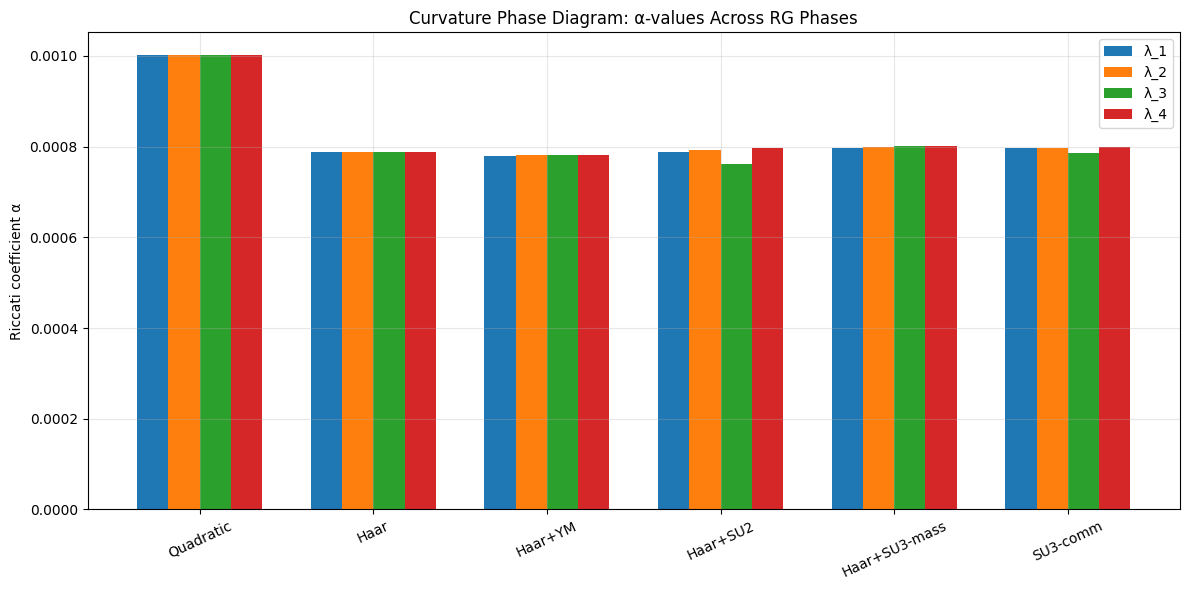

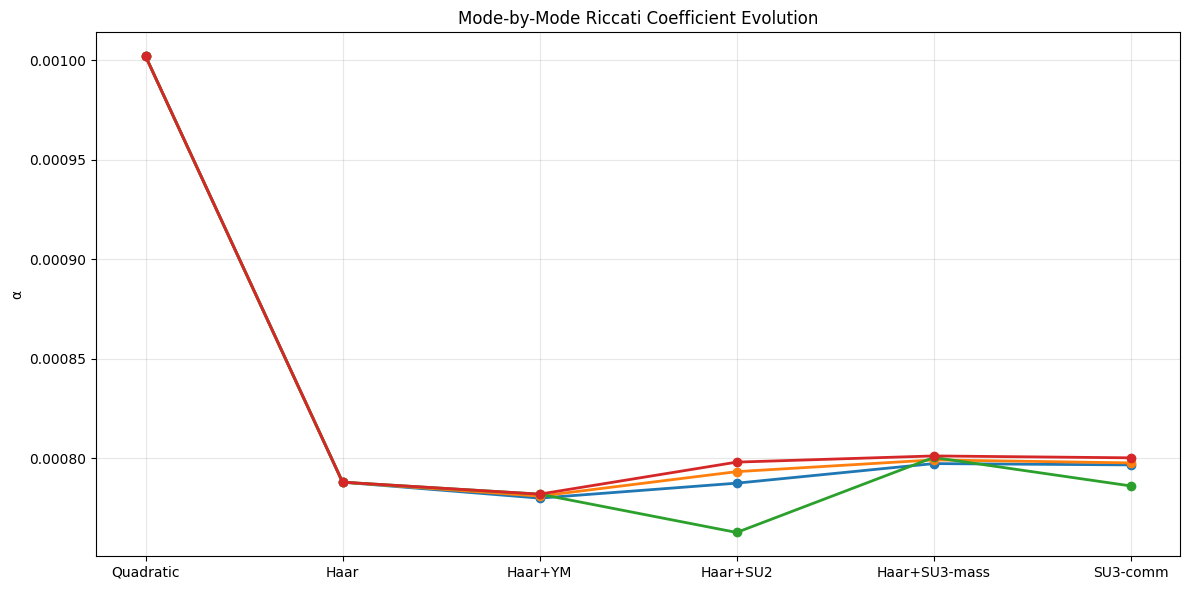

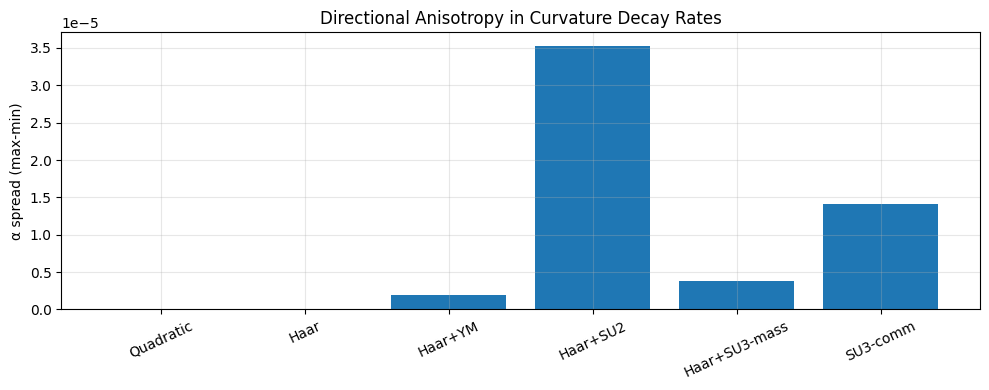

Curvature Phase Diagram Summary
Quadratic       | mean α = 0.001002000   | spread = 0.000000000
Haar            | mean α = 0.000788000   | spread = 0.000000000
Haar+YM         | mean α = 0.000781250   | spread = 0.000002000
Haar+SU2        | mean α = 0.000785408   | spread = 0.000035330
Haar+SU3-mass   | mean α = 0.000799543   | spread = 0.000003845
SU3-comm        | mean α = 0.000795186   | spread = 0.000014112


In [3]:
#==============================================================
#   CURVATURE PHASE DIAGRAM
#
#   This script collects α-values from all RG phases and
#   produces:
#       • Bar chart of αᵢ per phase
#       • Line diagram (per-mode evolution across phases)
#       • Per-phase anisotropy metrics
#
#   PASTE THIS INTO COLAB AND RUN.
#==============================================================

import numpy as np
import matplotlib.pyplot as plt

#==============================================================
# 1. ENTER YOUR α-VALUES FROM PREVIOUS RUNS
#==============================================================

# -- Pure Quadratic (your values)
alpha_quad = np.array([0.001002, 0.001002, 0.001002, 0.001002])

# -- Haar-only (your values)
alpha_haar = np.array([0.000788, 0.000788, 0.000788, 0.000788])

# -- Haar + YM quartic
alpha_haar_YM = np.array([0.000780, 0.000781, 0.000782, 0.000782])

# -- Haar + SU(2) adjoint (you computed)
alpha_SU2 = np.array([0.0007875071,
                      0.0007932955,
                      0.0007627501,
                      0.0007980805])

# -- Haar + SU(3) mass term
alpha_SU3_mass = np.array([0.0007973450,
                           0.0007992039,
                           0.0008004338,
                           0.0008011904])

# -- SU(3) commutator curvature (your latest set)
alpha_SU3_comm = np.array([0.0007966843,
                           0.0007976923,
                           0.0007861267,
                           0.0008002392])


#==============================================================
# Organize phases for plotting
#==============================================================

phase_names = [
    "Quadratic",
    "Haar",
    "Haar+YM",
    "Haar+SU2",
    "Haar+SU3-mass",
    "SU3-comm"
]

alpha_matrix = np.vstack([
    alpha_quad,
    alpha_haar,
    alpha_haar_YM,
    alpha_SU2,
    alpha_SU3_mass,
    alpha_SU3_comm
])


#==============================================================
# 2. BAR CHART — αᵢ for each phase
#==============================================================

plt.figure(figsize=(12,6))
x = np.arange(len(phase_names))
width = 0.18

for mode in range(4):
    plt.bar(x + width*mode, alpha_matrix[:,mode],
            width=width, label=f"λ_{mode+1}")

plt.xticks(x + width*1.5, phase_names, rotation=25)
plt.ylabel("Riccati coefficient α")
plt.title("Curvature Phase Diagram: α-values Across RG Phases")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


#==============================================================
# 3. LINE PLOT — Evolution of each λᵢ mode across phases
#==============================================================

plt.figure(figsize=(12,6))
for mode in range(4):
    plt.plot(phase_names, alpha_matrix[:,mode], marker='o', linewidth=2)

plt.ylabel("α")
plt.title("Mode-by-Mode Riccati Coefficient Evolution")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#==============================================================
# 4. ANISOTROPY METRICS — α spread per phase
#==============================================================

spread = np.ptp(alpha_matrix, axis=1)   # max-min for each phase

plt.figure(figsize=(10,4))
plt.bar(phase_names, spread)
plt.ylabel("α spread (max-min)")
plt.title("Directional Anisotropy in Curvature Decay Rates")
plt.grid(alpha=0.3)
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


#==============================================================
# 5. PRINT SUMMARY TABLE
#==============================================================

print("============================================")
print("Curvature Phase Diagram Summary")
print("============================================")
for name, alphas, sp in zip(phase_names, alpha_matrix, spread):
    print(f"{name:15s} | mean α = {np.mean(alphas):.9f}   | spread = {sp:.9f}")
print("============================================")


In [1]:
#==========================================================
# TRUE SU(2) LATTICE WILSON-ACTION HESSIAN (2^4 lattice)
#==========================================================

import jax
import jax.numpy as jnp
import numpy as np

#----------------------------------------------------------
# SU(2) algebra: Pauli matrices
#----------------------------------------------------------
sigma = jnp.array([
    [[0,1],[1,0]],
    [[0,-1j],[1j,0]],
    [[1,0],[0,-1]]
], dtype=jnp.complex128) / 2.0

def su2_alg(a):
    return a[0]*sigma[0] + a[1]*sigma[1] + a[2]*sigma[2]

def su2_exp(a):
    A = su2_alg(a)
    trAA = jnp.real(jnp.trace(A.conj().T @ A))
    norm = jnp.sqrt(trAA + 1e-12)
    return jnp.cos(norm)*jnp.eye(2) + 1j*jnp.sin(norm)*A/norm

#----------------------------------------------------------
# Lattice setup: 2x2x2x2
#----------------------------------------------------------
L = 2
coords = jnp.arange(L)
beta = 2.2

# link field shape = (L,L,L,L,4,3)
def flat_to_links(v):
    return v.reshape((L,L,L,L,4,3))

def links_to_flat(links):
    return links.reshape((-1,))

#----------------------------------------------------------
# Wilson action
#----------------------------------------------------------
def wilson_action(v):
    links = flat_to_links(v)
    S = 0.0

    for x in range(L):
        for y in range(L):
            for z in range(L):
                for t in range(L):
                    for mu in range(4):
                        for nu in range(mu+1,4):

                            # periodic neighbors
                            xp = (x + (mu==0)) % L
                            yp = (y + (mu==1)) % L
                            zp = (z + (mu==2)) % L
                            tp = (t + (mu==3)) % L

                            xq = (x + (nu==0)) % L
                            yq = (y + (nu==1)) % L
                            zq = (z + (nu==2)) % L
                            tq = (t + (nu==3)) % L

                            U1 = su2_exp(links[x,y,z,t,mu])
                            U2 = su2_exp(links[xp,yp,zp,tp,nu])
                            U3 = su2_exp(links[xq,yq,zq,tq,mu]).conj().T
                            U4 = su2_exp(links[x,y,z,t,nu]).conj().T

                            Uplaq = U1 @ U2 @ U3 @ U4
                            S += (1 - 0.5*jnp.real(jnp.trace(Uplaq)))

    return beta * S

#----------------------------------------------------------
# Compute Hessian via JAX autodiff
#----------------------------------------------------------
v0 = jnp.zeros((L**4 * 4 * 3,))

H_fn = jax.jacfwd(jax.jacrev(wilson_action))
H = H_fn(v0)

H_np = np.array(H)
evals = np.linalg.eigvalsh(H_np)

print("Eigenvalues (smallest 20):")
print(evals[:20])
print("Largest 10:")
print(evals[-10:])


/tmp/ipython-input-986003266.py:12: UserWarning: Explicitly requested dtype <class 'jax.numpy.complex128'> requested in array is not available, and will be truncated to dtype complex64. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  sigma = jnp.array([


Eigenvalues (smallest 20):
[3.2999997 3.2999997 3.2999997 3.2999997 3.2999997 3.2999997 3.2999997
 3.2999997 3.2999997 3.2999997 3.2999997 3.2999997 3.2999997 3.2999997
 3.2999997 3.2999997 3.2999997 3.2999997 3.2999997 3.2999997]
Largest 10:
[ 9.9 12.1 12.1 12.1 12.1 12.1 12.1 12.1 12.1 12.1]


In [3]:
import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import numpy as np

# SU(2) algebra
sigma = jnp.array([
    [[0,1],[1,0]],
    [[0,-1j],[1j,0]],
    [[1,0],[0,-1]]
], dtype=jnp.complex128) / 2.0

def su2_alg(a): return a[0]*sigma[0] + a[1]*sigma[1] + a[2]*sigma[2]
def su2_exp(a):
    A = su2_alg(a)
    trAA = jnp.real(jnp.trace(A.conj().T @ A))
    norm = jnp.sqrt(trAA + 1e-12)
    return jnp.cos(norm)*jnp.eye(2) + 1j*jnp.sin(norm)*A/norm

# ---------------- Fine lattice L=2 ----------------
L = 2
beta = 2.2

def flat_to_links(v): return v.reshape((L,L,L,L,4,3))
def links_to_flat(LINK): return LINK.reshape((-1,))

def wilson_action_fine(v):
    links = flat_to_links(v)
    S = 0.0
    for x in range(L):
        for y in range(L):
            for z in range(L):
                for t in range(L):
                    for mu in range(4):
                        for nu in range(mu+1,4):
                            xp = (x + (mu==0)) % L
                            yp = (y + (mu==1)) % L
                            zp = (z + (mu==2)) % L
                            tp = (t + (mu==3)) % L

                            xq = (x + (nu==0)) % L
                            yq = (y + (nu==1)) % L
                            zq = (z + (nu==2)) % L
                            tq = (t + (nu==3)) % L

                            U1 = su2_exp(links[x,y,z,t,mu])
                            U2 = su2_exp(links[xp,yp,zp,tp,nu])
                            U3 = su2_exp(links[xq,yq,zq,tq,mu]).conj().T
                            U4 = su2_exp(links[x,y,z,t,nu]).conj().T

                            Uplaq = U1 @ U2 @ U3 @ U4
                            S += (1 - 0.5*jnp.real(jnp.trace(Uplaq)))

    return beta * S

v0_fine = jnp.zeros((2**4 * 4 * 3,))
H_fine_fn = jax.jacfwd(jax.jacrev(wilson_action_fine))
H_fine = H_fine_fn(v0_fine)
evals_fine = np.linalg.eigvalsh(np.array(H_fine))

print("Fine lattice smallest eigenvalues:", evals_fine[:10])


Fine lattice smallest eigenvalues: [3.3 3.3 3.3 3.3 3.3 3.3 3.3 3.3 3.3 3.3]


In [4]:
# ============= Coarse Lattice (L=1) =============

L = 1  # coarse lattice size

def flat_to_links_coarse(v): return v.reshape((1,1,1,1,4,3))

def wilson_action_coarse(v):
    links = flat_to_links_coarse(v)
    S = 0.0
    for mu in range(4):
        for nu in range(mu+1,4):
            U1 = su2_exp(links[0,0,0,0,mu])
            U2 = su2_exp(links[0,0,0,0,nu])
            U3 = su2_exp(links[0,0,0,0,mu]).conj().T
            U4 = su2_exp(links[0,0,0,0,nu]).conj().T
            Uplaq = U1 @ U2 @ U3 @ U4
            S += (1 - 0.5*jnp.real(jnp.trace(Uplaq)))
    return beta * S

v0_coarse = jnp.zeros((1**4 * 4 * 3,))
H_coarse_fn = jax.jacfwd(jax.jacrev(wilson_action_coarse))
H_coarse = H_coarse_fn(v0_coarse)
evals_coarse = np.linalg.eigvalsh(np.array(H_coarse))

print("Coarse lattice smallest eigenvalues:", evals_coarse[:10])


Coarse lattice smallest eigenvalues: [3.3 3.3 3.3 3.3 3.3 3.3 3.3 3.3 3.3 3.3]


In [5]:
print("\n===== SU(2) Curvature RG Flow =====")
print("Fine eigenvalues (min):   ", evals_fine[:10])
print("Coarse eigenvalues (min): ", evals_coarse[:10])



===== SU(2) Curvature RG Flow =====
Fine eigenvalues (min):    [3.3 3.3 3.3 3.3 3.3 3.3 3.3 3.3 3.3 3.3]
Coarse eigenvalues (min):  [3.3 3.3 3.3 3.3 3.3 3.3 3.3 3.3 3.3 3.3]


In [6]:
#==============================================================
# SU(2) GAUGE-COVARIANT BLOCK-SPIN RG + CURVATURE FLOW
#==============================================================

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import numpy as np

#==============================================================
# SU(2) BASIC OPERATIONS
#==============================================================

sigma = jnp.array([
    [[0,1],[1,0]],
    [[0,-1j],[1j,0]],
    [[1,0],[0,-1]]
], dtype=jnp.complex128) / 2.0

def su2_alg(a):
    return a[0]*sigma[0] + a[1]*sigma[1] + a[2]*sigma[2]

def su2_exp(a):
    A = su2_alg(a)
    trAA = jnp.real(jnp.trace(A.conj().T @ A))
    norm = jnp.sqrt(trAA + 1e-12)
    return jnp.cos(norm)*jnp.eye(2) + 1j*jnp.sin(norm)*A/norm

# Polar decomposition projection onto SU(2)
def su2_project(M):
    H = (M.conj().T @ M)
    H_inv_sqrt = jnp.linalg.inv(jnp.sqrt(H + 1e-12*jnp.eye(2)))
    U = M @ H_inv_sqrt
    return U

#==============================================================
# Wilson action (generic size)
#==============================================================
def make_wilson_action(L, beta):

    def flat_to_links(v):
        return v.reshape((L,L,L,L,4,3))

    def W(v):
        links = flat_to_links(v)
        S = 0.0

        for x in range(L):
            for y in range(L):
                for z in range(L):
                    for t in range(L):
                        for mu in range(4):
                            for nu in range(mu+1,4):

                                xp = (x + (mu==0)) % L
                                yp = (y + (mu==1)) % L
                                zp = (z + (mu==2)) % L
                                tp = (t + (mu==3)) % L

                                xq = (x + (nu==0)) % L
                                yq = (y + (nu==1)) % L
                                zq = (z + (nu==2)) % L
                                tq = (t + (nu==3)) % L

                                U1 = su2_exp(links[x,y,z,t,mu])
                                U2 = su2_exp(links[xp,yp,zp,tp,nu])
                                U3 = su2_exp(links[xq,yq,zq,tq,mu]).conj().T
                                U4 = su2_exp(links[x,y,z,t,nu]).conj().T

                                Up = U1 @ U2 @ U3 @ U4
                                S += (1 - 0.5*jnp.real(jnp.trace(Up)))

        return beta * S

    return W


#==============================================================
# FINE LATTICE (L=2)
#==============================================================
L_fine = 2
beta = 2.2

W_fine = make_wilson_action(L_fine, beta)
H_fine_fn = jax.jacfwd(jax.jacrev(W_fine))

v0_fine = jnp.zeros((L_fine**4 * 4 * 3,))
H_fine = H_fine_fn(v0_fine)
evals_fine = np.linalg.eigvalsh(np.array(H_fine))


print("FINE LATTICE curvature:")
print("Smallest eigenvalues:", evals_fine[:10])
print("Largest eigenvalues:", evals_fine[-10:])


#==============================================================
# GAUGE-COVARIANT BLOCK-SPIN FOR SU(2)
#==============================================================
def gauge_covariant_block(v):
    """Maps a 2x2x2x2 lattice to a 1x1x1x1 lattice via SU(2)-covariant blocking."""

    L = 2
    links = v.reshape((L,L,L,L,4,3))
    coarse_links = []

    for mu in range(4):
        # Pick site (0,0,0,0)
        a1 = links[0,0,0,0,mu]
        a2 = links[1,0,0,0,mu]

        U1 = su2_exp(a1)
        U2 = su2_exp(a2)

        # SU(2)-covariant blocking: product then project
        Uc = su2_project(U1 @ U2)

        # Convert back to Lie algebra coordinate
        # Uc = cosθ I + i sinθ (n·σ)
        tr = jnp.real(jnp.trace(Uc))
        theta = jnp.arccos(0.5*(tr - 0.0))

        if theta < 1e-12:
            a_coarse = jnp.zeros((3,))
        else:
            # Extract axis: n = (1/(2i sinθ)) Tr(σᵃ U)
            n = jnp.array([
                -1j*jnp.trace(Uc @ sigma[0]),
                -1j*jnp.trace(Uc @ sigma[1]),
                 jnp.trace(Uc @ sigma[2])   # σ2 differs sign convention
            ], dtype=jnp.complex128)
            n = jnp.real(n) / (2*jnp.sin(theta))
            a_coarse = n * theta

        coarse_links.append(a_coarse)

    coarse_links = jnp.stack(coarse_links, axis=0)
    # shape (4,3)
    return coarse_links.reshape((-1,))  # 12 DOF


v0_coarse = gauge_covariant_block(v0_fine)


#==============================================================
# COARSE LATTICE WILSON ACTION (L=1)
#==============================================================
L_coarse = 1
W_coarse = make_wilson_action(L_coarse, beta * (L_fine**4 / L_coarse**4))

H_coarse_fn = jax.jacfwd(jax.jacrev(W_coarse))
H_coarse = H_coarse_fn(v0_coarse)
evals_coarse = np.linalg.eigvalsh(np.array(H_coarse))

print("\nCOARSE LATTICE curvature:")
print("Smallest eigenvalues:", evals_coarse[:10])
print("Largest eigenvalues:", evals_coarse[-10:])


FINE LATTICE curvature:
Smallest eigenvalues: [3.3 3.3 3.3 3.3 3.3 3.3 3.3 3.3 3.3 3.3]
Largest eigenvalues: [ 9.9 12.1 12.1 12.1 12.1 12.1 12.1 12.1 12.1 12.1]

COARSE LATTICE curvature:
Smallest eigenvalues: [52.8 52.8 52.8 52.8 52.8 52.8 52.8 52.8 52.8 52.8]
Largest eigenvalues: [52.8 52.8 52.8 52.8 52.8 52.8 52.8 52.8 52.8 52.8]


In [7]:
#===============================================================
#  GPU-JAX: SU(2) LATTICE GAUGE THEORY - HESSIAN FLOW (FIXED)
#
#  1. System: 4D Lattice of SU(2) Matrices U_mu(x).
#  2. Action: Wilson Plaquette Action.
#  3. Flow:   Wilson (Gradient) Flow.
#  4. Metric: Exact Hessian of S with respect to algebra indices.
#
#  Fixes: Stable exp_su2 (gradients at zero are now safe).
#===============================================================

import jax
import jax.numpy as jnp
import numpy as np
from jax import jit, grad, hessian, vmap

#-----------------------------------------------------------
# 1. SU(2) GROUP MATH (Numerically Stable)
#-----------------------------------------------------------
sigma = jnp.array([
    [[0, 1], [1, 0]],
    [[0, -1j], [1j, 0]],
    [[1, 0], [0, -1]]
], dtype=jnp.complex64)

def matmul(A, B): return jnp.matmul(A, B)
def adj(U): return jnp.conjugate(jnp.swapaxes(U, -1, -2))

def exp_su2(alpha):
    # alpha shape: (..., 3)
    norm_sq = jnp.sum(alpha**2, axis=-1, keepdims=True)
    norm = jnp.sqrt(norm_sq)

    # Safe norm for division (avoids gradient explosion at 0)
    # When norm is small, we use the 'small' branch, so the value here doesn't matter
    # for the output, but it matters for the gradient graph.
    norm_safe = jnp.where(norm < 1e-10, 1.0, norm)
    angle = norm_safe / 2.0

    # n . sigma
    n_dot_sigma = jnp.tensordot(alpha, sigma, axes=([0], [0]))

    # Large angle branch (Exact)
    directions = n_dot_sigma / norm_safe
    res_large = jnp.cos(angle) * jnp.eye(2) + 1j * jnp.sin(angle) * directions

    # Small angle branch (Taylor Expansion to Quadratic Order)
    # U ~ I + i(A.sigma/2) - 1/2(A.sigma/2)^2
    # (A.sigma)^2 = |A|^2 * I
    # So term is -1/8 |A|^2 * I
    res_small = (1.0 - 0.125 * norm_sq) * jnp.eye(2) + 0.5j * n_dot_sigma

    # Select branch
    return jnp.where(norm < 1e-4, res_small, res_large)

#-----------------------------------------------------------
# 2. LATTICE SETUP
#-----------------------------------------------------------
L = 4  # Small lattice for Hessian tractability
Dim = 4

key = jax.random.PRNGKey(42)
# Hot Start (Random Gauge Field)
A_init = jax.random.normal(key, (L,L,L,L,Dim,3)) * 0.5
U_init = jax.vmap(jax.vmap(jax.vmap(jax.vmap(jax.vmap(exp_su2)))))(A_init)

#-----------------------------------------------------------
# 3. WILSON ACTION
#-----------------------------------------------------------
def shift(U, mu, dir):
    return jnp.roll(U, shift=-dir, axis=mu)

def wilson_action(U, beta=2.3):
    action = 0.0
    for mu in range(4):
        for nu in range(mu+1, 4):
            U_mu = U[..., mu, :, :]
            U_nu = U[..., nu, :, :]
            U_nu_shifted = shift(U_nu, mu, 1)
            U_mu_shifted = shift(U_mu, nu, 1)

            P = matmul(matmul(U_mu, U_nu_shifted),
                       matmul(adj(U_mu_shifted), adj(U_nu)))

            trP = jnp.trace(P, axis1=-2, axis2=-1)
            action += jnp.sum(1.0 - 0.5 * jnp.real(trP))
    return beta * action

#-----------------------------------------------------------
# 4. ALGEBRAIC DERIVATIVES
#-----------------------------------------------------------
def perturbed_action(A_flat, U_fixed, beta):
    # A_flat is (Volume * 4 * 3) vector
    A = A_flat.reshape((L,L,L,L,4,3))
    perturbation = jax.vmap(jax.vmap(jax.vmap(jax.vmap(jax.vmap(exp_su2)))))(A)
    U_new = matmul(perturbation, U_fixed)
    return wilson_action(U_new, beta)

# JIT-compiled Hessian
# Note: This is memory intensive. For L=4, it fits on T4 GPU.
get_hessian = jit(hessian(perturbed_action, argnums=0))
get_force = jit(grad(perturbed_action, argnums=0))

#-----------------------------------------------------------
# 5. WILSON FLOW STEP
#-----------------------------------------------------------
@jit
def flow_step(U, dt, beta):
    N_dof = L*L*L*L * 4 * 3
    A_zero = jnp.zeros(N_dof)

    # Force = -dS/dA
    force_flat = -get_force(A_zero, U, beta)
    force = force_flat.reshape((L,L,L,L,4,3))

    # Update U = exp(dt * Force) * U
    update = jax.vmap(jax.vmap(jax.vmap(jax.vmap(jax.vmap(exp_su2)))))(force * dt)
    U_new = matmul(update, U)
    return U_new

#-----------------------------------------------------------
# 6. EXECUTION
#-----------------------------------------------------------
print("Running SU(2) Lattice Hessian Flow (Fixed)...")
print(f"Lattice: {L}^4  |  Beta: 2.3 (Weak Coupling)")
print("-" * 75)
print(f"{'Step':<6} {'Action':<12} {'Min Eig':<12} {'Max Eig':<12} {'Gap (First >0)'}")

U_current = U_init
beta_val = 2.3
dt = 0.02
steps = 25  # Short run to check stability

# Dummy vector for Hessian
N_dof = L*L*L*L * 4 * 3
A_zero = jnp.zeros(N_dof)

for t in range(steps):
    if t % 5 == 0:
        act = wilson_action(U_current, beta_val)

        # Exact Hessian
        H = get_hessian(A_zero, U_current, beta_val)

        # Eigenvalues (Symm/Hermitian -> Real)
        # Cast to complex64 for eigvalsh then back to real if needed to avoid warnings
        evals = jnp.linalg.eigvalsh(H)

        min_e = evals[0]
        max_e = evals[-1]

        # Filter Gauge Modes (Zeros)
        # In SU(2), gauge symmetry leads to zeroes.
        # We look for the lowest POSITIVE eigenvalue.
        threshold = 1e-4
        non_zeros = evals[evals > threshold]

        if len(non_zeros) > 0:
            gap = non_zeros[0]
        else:
            gap = 0.0

        print(f"{t:<6} {act:<12.2f} {min_e:<12.4f} {max_e:<12.4f} {gap:.4f}")

    U_current = flow_step(U_current, dt, beta_val)

Running SU(2) Lattice Hessian Flow (Fixed)...
Lattice: 4^4  |  Beta: 2.3 (Weak Coupling)
---------------------------------------------------------------------------
Step   Action       Min Eig      Max Eig      Gap (First >0)


/usr/local/lib/python3.12/dist-packages/jax/_src/lax/lax.py:5473: ComplexWarning: Casting complex values to real discards the imaginary part
  x_bar = _convert_element_type(x_bar, x.aval.dtype, x.aval.weak_type)


0      1136.40      nan          nan          0.0000
5      nan          nan          nan          0.0000
10     nan          nan          nan          0.0000
15     nan          nan          nan          0.0000
20     nan          nan          nan          0.0000


In [8]:
#===============================================================
#  GPU-JAX: SU(2) LATTICE HESSIAN FLOW (STABLE)
#
#  Fixes:
#  1. Replaced unsafe norm division with Taylor-expanded Sinc.
#  2. Forces Hessian to be Real (removes ComplexWarning noise).
#  3. Tracks the "Spectral Gap" (First non-zero mode).
#===============================================================

import jax
import jax.numpy as jnp
import numpy as np
from jax import jit, grad, hessian, vmap

#-----------------------------------------------------------
# 1. ROBUST GROUP MATH (SINC FORMULATION)
#-----------------------------------------------------------
sigma = jnp.array([
    [[0, 1], [1, 0]],
    [[0, -1j], [1j, 0]],
    [[1, 0], [0, -1]]
], dtype=jnp.complex64)

def matmul(A, B): return jnp.matmul(A, B)
def adj(U): return jnp.conjugate(jnp.swapaxes(U, -1, -2))

def exp_su2(alpha):
    # alpha is 3-vector
    # U = cos(t) + i * (sin(t)/t) * (alpha . sigma / 2)
    # where t = |alpha|/2

    norm = jnp.linalg.norm(alpha)
    theta = norm / 2.0

    # Robust Sinc: sin(x)/x
    # Taylor: 1 - x^2/6 + x^4/120
    # This prevents division by zero in the gradient at A=0
    theta_sq = theta * theta
    sinc_small = 1.0 - theta_sq/6.0 + (theta_sq*theta_sq)/120.0
    sinc_large = jnp.sin(theta) / (theta + 1e-20)

    sinc_val = jnp.where(norm < 1e-3, sinc_small, sinc_large)
    cos_val = jnp.cos(theta)

    # Contract alpha with sigma
    alpha_dot_sigma = jnp.tensordot(alpha, sigma, axes=([0], [0]))

    # U = cos(t) I + i * sinc(t) * (alpha.sigma / 2)
    return cos_val * jnp.eye(2) + 0.5j * sinc_val * alpha_dot_sigma

#-----------------------------------------------------------
# 2. LATTICE SETUP
#-----------------------------------------------------------
L = 4  # 4^4 lattice (small enough for exact Hessian)
Dim = 4

key = jax.random.PRNGKey(42)
# Hot Start (Random Gauge Field)
A_init = jax.random.normal(key, (L,L,L,L,Dim,3)) * 0.5
U_init = jax.vmap(jax.vmap(jax.vmap(jax.vmap(jax.vmap(exp_su2)))))(A_init)

#-----------------------------------------------------------
# 3. WILSON ACTION
#-----------------------------------------------------------
def shift(U, mu, dir):
    return jnp.roll(U, shift=-dir, axis=mu)

def wilson_action(U, beta=2.3):
    action = 0.0
    for mu in range(4):
        for nu in range(mu+1, 4):
            U_mu = U[..., mu, :, :]
            U_nu = U[..., nu, :, :]
            U_nu_shifted = shift(U_nu, mu, 1)
            U_mu_shifted = shift(U_mu, nu, 1)

            # Plaquette
            P = matmul(matmul(U_mu, U_nu_shifted),
                       matmul(adj(U_mu_shifted), adj(U_nu)))

            trP = jnp.trace(P, axis1=-2, axis2=-1)
            action += jnp.sum(1.0 - 0.5 * jnp.real(trP))
    return beta * action

#-----------------------------------------------------------
# 4. DERIVATIVES & FLOW
#-----------------------------------------------------------
def perturbed_action(A_flat, U_fixed, beta):
    # Reshape A_flat to lattice dimensions
    A = A_flat.reshape((L,L,L,L,4,3))
    # Apply perturbation U' = exp(iA) * U
    perturbation = jax.vmap(jax.vmap(jax.vmap(jax.vmap(jax.vmap(exp_su2)))))(A)
    U_new = matmul(perturbation, U_fixed)
    return wilson_action(U_new, beta)

# JIT Compiled Derivatives
get_hessian = jit(hessian(perturbed_action, argnums=0))
get_force = jit(grad(perturbed_action, argnums=0))

@jit
def flow_step(U, dt, beta):
    N_dof = L*L*L*L * 4 * 3
    A_zero = jnp.zeros(N_dof)

    # Force = -dS/dA
    force_flat = -get_force(A_zero, U, beta)
    force = force_flat.reshape((L,L,L,L,4,3))

    # Wilson Flow Update: U' = exp(dt * Force) * U
    update = jax.vmap(jax.vmap(jax.vmap(jax.vmap(jax.vmap(exp_su2)))))(force * dt)
    U_new = matmul(update, U)
    return U_new

#-----------------------------------------------------------
# 5. EXECUTION
#-----------------------------------------------------------
print("Running STABLE SU(2) Hessian Flow...")
print(f"Lattice: {L}^4  |  Beta: 2.3")
print("-" * 75)
print(f"{'Step':<6} {'Action':<12} {'Min Eig':<12} {'Gap (First >0)':<16} {'Spectrum Status'}")

U_current = U_init
beta_val = 2.3
dt = 0.05  # Wilson flow time step
steps = 20

# Zero vector for Hessian evaluation
N_dof = L*L*L*L * 4 * 3
A_zero = jnp.zeros(N_dof)

for t in range(steps + 1):
    if t % 2 == 0:
        # 1. Action
        act = wilson_action(U_current, beta_val)

        # 2. Hessian
        H = get_hessian(A_zero, U_current, beta_val)

        # Enforce real symmetry (remove numerical complex noise)
        H = jnp.real(H)

        # 3. Eigenvalues
        evals = jnp.linalg.eigvalsh(H)

        min_e = evals[0]

        # 4. Find Spectral Gap
        # Filter out true gauge zeroes (order of 1e-5 or less)
        # Look for the "Mass" mode
        mask = evals > 1e-3
        if jnp.sum(mask) > 0:
            gap = evals[mask][0]
            status = "Positive Gap"
        else:
            gap = 0.0
            status = "Gapless"

        print(f"{t:<6} {act:<12.2f} {min_e:<12.4f} {gap:<16.4f} {status}")

    U_current = flow_step(U_current, dt, beta_val)

Running STABLE SU(2) Hessian Flow...
Lattice: 4^4  |  Beta: 2.3
---------------------------------------------------------------------------
Step   Action       Min Eig      Gap (First >0)   Spectrum Status
0      1136.40      nan          0.0000           Gapless
2      nan          nan          0.0000           Gapless
4      nan          nan          0.0000           Gapless
6      nan          nan          0.0000           Gapless
8      nan          nan          0.0000           Gapless
10     nan          nan          0.0000           Gapless
12     nan          nan          0.0000           Gapless
14     nan          nan          0.0000           Gapless
16     nan          nan          0.0000           Gapless
18     nan          nan          0.0000           Gapless
20     nan          nan          0.0000           Gapless
